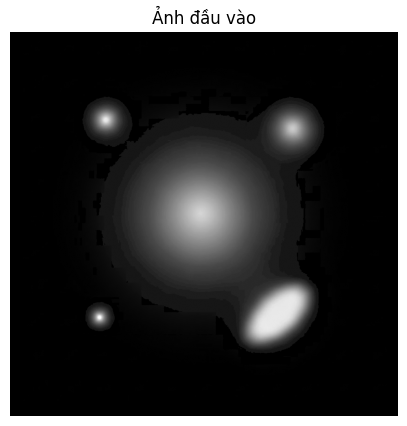

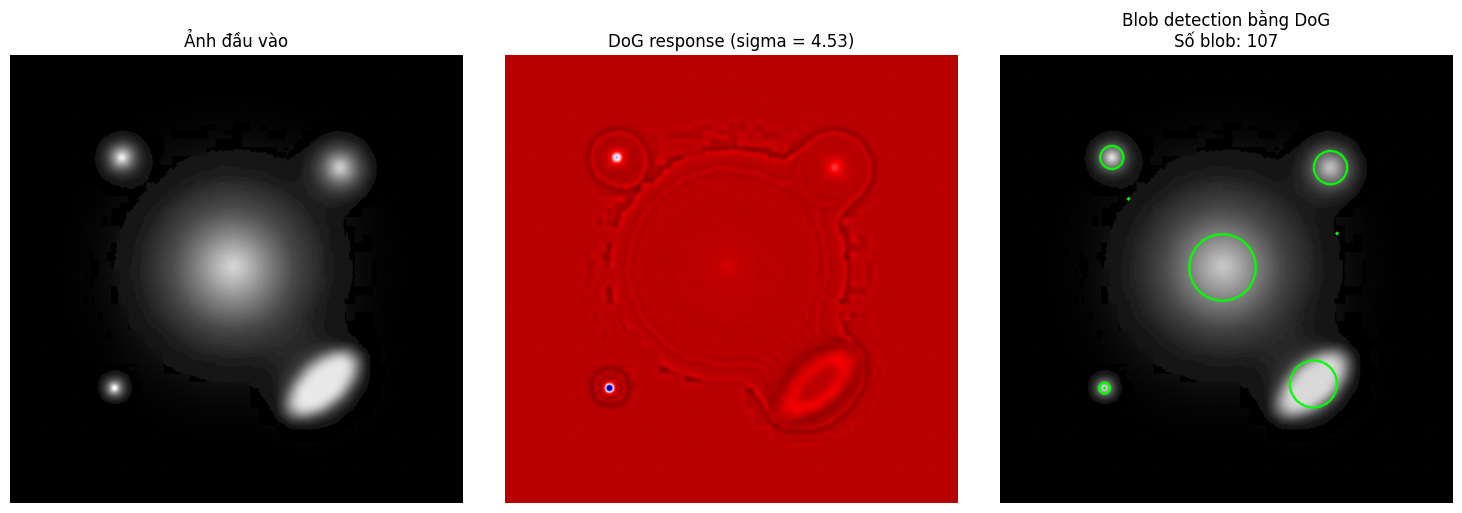

Kiểm tra kết quả:
- Kích thước ảnh đầu vào: (973, 982)
- Số mức DoG: 11
- Số blob phát hiện được: 107
- Khoảng giá trị DoG tại mức 3: [-0.2441, 0.0317]


In [ ]:
# ============================================================
# GIÁO TRÌNH: THỊ GIÁC MÁY: TỪ XỬ LÝ ẢNH ĐẾN HỌC SÂU
# BÀI CODE MINH HỌA: PHÁT HIỆN BLOB BẰNG DoG
# Chương/Mục liên quan: Chương 5 - Điểm đặc trưng và vùng đặc trưng
# ============================================================

# ============================================================
# MÔ TẢ
# ============================================================

# Mục đích:
# - Minh họa phát hiện blob bằng Difference of Gaussian trên không gian đa tỉ lệ.
# - Giúp người học quan sát đáp ứng DoG tại một mức tỉ lệ.
# - Liên hệ việc tìm cực trị cục bộ trong không gian tỉ lệ với phát hiện blob.

# Input:
# - Ảnh xám từ GitHub: blobs.png

# Output:
# - Ảnh đầu vào
# - Một lát đáp ứng DoG
# - Ảnh kết quả có đánh dấu blob phát hiện được

# Lưu ý:
# Đoạn code này được xây dựng với sự hỗ trợ của công cụ AI.
# Giảng viên đã đọc, kiểm tra và hiệu chỉnh nhằm bảo đảm tính chính xác,
# tính sư phạm và sự phù hợp với nội dung lý thuyết trong giáo trình.

# ============================================================
# 1. CÀI ĐẶT VÀ IMPORT THƯ VIỆN
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt

from urllib.request import urlopen
from scipy.ndimage import gaussian_filter, maximum_filter, minimum_filter

# ============================================================
# 2. TẢI DỮ LIỆU ĐẦU VÀO
# ============================================================

def read_gitlab_image(url):
    resp = urlopen(url)
    img = np.asarray(bytearray(resp.read()), dtype=np.uint8)
    return cv2.imdecode(img, cv2.IMREAD_GRAYSCALE)


image_uri = "https://github.com/lthavnu/cv-book/raw/main/images/blobs.png"
I_gray = read_gitlab_image(image_uri)

# ============================================================
# 3. HIỂN THỊ ẢNH ĐẦU VÀO
# ============================================================

plt.figure(figsize=(5, 5))
plt.imshow(I_gray, cmap="gray")
plt.title("Ảnh đầu vào")
plt.axis("off")
plt.show()

# ============================================================
# 4. XỬ LÝ CHÍNH
# ============================================================

def detect_blobs_dog(I_gray, sigma0=1.6, k=np.sqrt(2), num_scales=12, threshold=0.03):
    # Chuyển ảnh sang float32 trong khoảng [0, 1]
    I_gray = I_gray.astype(np.float32) / 255.0

    # Tạo danh sách các giá trị sigma
    sigmas = [sigma0 * (k ** i) for i in range(num_scales)]

    # Tạo Gaussian scale-space
    gaussian_pyramid = []
    for sigma in sigmas:
        G = gaussian_filter(I_gray, sigma=sigma)
        gaussian_pyramid.append(G)

    # Tạo DoG scale-space
    # Dòng code dưới đây tương ứng với xấp xỉ:
    # S_B(x, y; sigma) ~= (G(x, y; k sigma) - G(x, y; sigma)) / (k - 1)
    dog_pyramid = []
    dog_sigmas = []

    for i in range(num_scales - 1):
        DoG = (gaussian_pyramid[i + 1] - gaussian_pyramid[i]) / (k - 1)
        dog_pyramid.append(DoG)
        dog_sigmas.append(sigmas[i])

    dog_pyramid = np.stack(dog_pyramid, axis=0)

    # Tìm cực đại và cực tiểu cục bộ trong không gian 3D: scale, y, x
    local_max = maximum_filter(dog_pyramid, size=(3, 3, 3))
    local_min = minimum_filter(dog_pyramid, size=(3, 3, 3))

    # Giữ lại các điểm cực trị có đáp ứng đủ mạnh
    max_mask = (dog_pyramid == local_max) & (np.abs(dog_pyramid) >= threshold)
    min_mask = (dog_pyramid == local_min) & (np.abs(dog_pyramid) >= threshold)
    extremum_mask = max_mask | min_mask

    # Lấy tọa độ các blob
    s_idx, y_idx, x_idx = np.where(extremum_mask)

    blobs = []

    for s, y, x in zip(s_idx, y_idx, x_idx):
        sigma = dog_sigmas[s]
        response = dog_pyramid[s, y, x]
        blobs.append((y, x, sigma, response))

    return blobs, dog_pyramid, dog_sigmas


def draw_blobs(I_gray, blobs, max_blobs=200):
    I_vis = cv2.cvtColor(I_gray, cv2.COLOR_GRAY2RGB)

    # Sắp xếp blob theo độ mạnh đáp ứng
    blobs = sorted(blobs, key=lambda b: abs(b[3]), reverse=True)[:max_blobs]

    for y, x, sigma, response in blobs:
        r = int(np.sqrt(2) * sigma)

        # Trong đoạn code gốc, chỉ vẽ các blob có response < 0
        if response < 0:
            color = (0, 255, 0)
            cv2.circle(I_vis, (int(x), int(y)), r, color, 3)

    return I_vis


def normalize_for_display(I):
    I = I - I.min()

    if I.max() > 0:
        I = I / I.max()

    return I


blobs, dog_pyramid, dog_sigmas = detect_blobs_dog(
    I_gray,
    sigma0=1.6,
    k=np.sqrt(2),
    num_scales=12,
    threshold=0.03
)

I_blob = draw_blobs(I_gray, blobs, max_blobs=300)

dog_level = 3
DoG_show = normalize_for_display(dog_pyramid[dog_level])

# ============================================================
# 5. HIỂN THỊ KẾT QUẢ
# ============================================================

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(I_gray, cmap="gray")
plt.title("Ảnh đầu vào")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(DoG_show, cmap="seismic")
plt.title(f"DoG response (sigma = {dog_sigmas[dog_level]:.2f})")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(I_blob)
plt.title(f"Blob detection bằng DoG\nSố blob: {len(blobs)}")
plt.axis("off")

plt.tight_layout()
plt.show()

# ============================================================
# 6. KIỂM TRA KẾT QUẢ
# ============================================================

assert I_gray is not None, "Lỗi: không đọc được ảnh đầu vào."
assert len(I_gray.shape) == 2, "Lỗi: ảnh đầu vào không phải ảnh xám."
assert dog_pyramid.shape[0] == len(dog_sigmas), "Lỗi: số mức DoG không khớp với số sigma."
assert dog_pyramid.shape[1:] == I_gray.shape, "Lỗi: kích thước DoG không khớp với ảnh đầu vào."
assert len(blobs) > 0, "Lỗi: không phát hiện được blob nào."

print("Kiểm tra kết quả:")
print(f"- Kích thước ảnh đầu vào: {I_gray.shape}")
print(f"- Số mức DoG: {dog_pyramid.shape[0]}")
print(f"- Số blob phát hiện được: {len(blobs)}")
print(f"- Khoảng giá trị DoG tại mức {dog_level}: [{dog_pyramid[dog_level].min():.4f}, {dog_pyramid[dog_level].max():.4f}]")

# ============================================================
# 7. GỢI Ý THỬ NGHIỆM CHO NGƯỜI HỌC
# ============================================================

# Có thể thay đổi threshold để quan sát số blob tăng hoặc giảm.
# Có thể thay đổi sigma0 để quan sát ảnh hưởng của tỉ lệ khởi đầu.
# Có thể thay đổi num_scales để quan sát số mức trong không gian tỉ lệ.